In [6]:
from statsbombpy import sb
comps = sb.competitions()
comps[comps['competition_international'] == True]

C:\Users\pryde\Documents\Football\Analysis\football-analytics\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
21,223,282,South America,Copa America,male,False,True,2024,2026-05-13T12:24:48.807600,NaN,NaN,2026-05-13T12:24:48.807600
29,1470,274,International,FIFA U20 World Cup,male,True,True,1979,2024-02-13T14:20:59.825440,NaN,NaN,2024-02-13T14:20:59.825440
30,43,106,International,FIFA World Cup,male,False,True,2022,2026-05-04T01:48:57.914346,2026-05-04T01:53:40.309717,2026-05-04T01:53:40.309717,2026-05-04T01:48:57.914346
31,43,3,International,FIFA World Cup,male,False,True,2018,2026-05-15T15:48:12.789440,2021-06-13T16:17:31.694,NaN,2026-05-15T15:48:12.789440
32,43,55,International,FIFA World Cup,male,False,True,1990,2023-06-28T10:58:20.137929,2021-06-12T16:17:31.694,NaN,2023-06-28T10:58:20.137929
33,43,54,International,FIFA World Cup,male,False,True,1986,2026-05-04T01:30:23.212111,2021-06-13T16:17:31.694,NaN,2026-05-04T01:30:23.212111
34,43,51,International,FIFA World Cup,male,False,True,1974,2026-05-15T02:20:43.439689,2021-06-13T16:17:31.694,NaN,2026-05-15T02:20:43.439689
35,43,272,International,FIFA World Cup,male,False,True,1970,2026-05-04T02:09:10.916859,NaN,NaN,2026-05-04T02:09:10.916859
36,43,270,International,FIFA World Cup,male,False,True,1962,2026-05-04T02:05:35.653887,NaN,NaN,2026-05-04T02:05:35.653887


In [7]:
matches = sb.matches(competition_id=223, season_id=282)
print(len(matches))

C:\Users\pryde\Documents\Football\Analysis\football-analytics\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


32


In [8]:
import pandas as pd

all_shots = []
for match_id in matches['match_id']:
    ev = sb.events(match_id)
    s = ev[ev['type'] == 'Shot']
    all_shots.append(s)

shots = pd.concat(all_shots, ignore_index=True)
print(f"Total shots: {len(shots)}")

C:\Users\pryde\Documents\Football\Analysis\football-analytics\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\pryde\Documents\Football\Analysis\football-analytics\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\pryde\Documents\Football\Analysis\football-analytics\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\pryde\Documents\Football\Analysis\football-analytics\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\pryde\Documents\Football\Analysis\football-analytics\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Total shots: 790


In [9]:
shots.columns.tolist()

['50_50',
 'bad_behaviour_card',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'block_offensive',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_right_foot',
 'counterpress',
 'dribble_no_touch',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_committed_offensive',
 'foul_committed_type',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',

In [11]:
import numpy as np

shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])
shots['distance_to_goal'] = np.sqrt((120 - shots['x'])**2 + (40 - shots['y'])**2) * 0.9144
shots['is_goal'] = (shots['shot_outcome'] == 'Goal').astype(int)

goal_width = 7.32
shots['angle'] = np.abs(np.arctan2(
    goal_width * (120 - shots['x']),
    (120 - shots['x'])**2 + np.abs(40 - shots['y']) * (np.abs(40 - shots['y']) + goal_width)
))

shots['is_header'] = (shots['shot_body_part'] == 'Head').astype(int)
shots['is_open_play'] = (shots['shot_type'] == 'Open Play').astype(int)
shots['under_pressure'] = shots['under_pressure'].fillna(False).astype(int)

model_data = shots.dropna(subset=['distance_to_goal', 'angle', 'is_goal', 'is_header', 'is_open_play', 'under_pressure'])
print(f"Shots available for modeling: {len(model_data)}")

Shots available for modeling: 790


In [14]:
import statsmodels.api as sm

features = ['distance_to_goal', 'angle', 'is_header', 'is_open_play', 'under_pressure']
X = sm.add_constant(model_data[features])
y = model_data['is_goal']

model = sm.Logit(y, X).fit(disp=0)
print(model.summary())

model_data['my_xg'] = model.predict(X)
model_data[['player', 'distance_to_goal', 'is_goal', 'my_xg', 'shot_statsbomb_xg']].head(15)

                           Logit Regression Results                           
Dep. Variable:                is_goal   No. Observations:                  790
Model:                          Logit   Df Residuals:                      784
Method:                           MLE   Df Model:                            5
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                  0.2022
Time:                        17:12:44   Log-Likelihood:                -231.57
converged:                       True   LL-Null:                       -290.27
Covariance Type:            nonrobust   LLR p-value:                 1.113e-23
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.5312      0.833      3.039      0.002       0.899       4.163
distance_to_goal    -0.1706      0.029     -5.817      0.000      -0.228      -0.113
angle               -0.4909 

,player,distance_to_goal,is_goal,my_xg,shot_statsbomb_xg
0,James David Rodríguez Rubio,30.319772,0,0.060889,0.020332
1,Bruno Guimarães Rodriguez Moura,21.016286,0,0.043990,0.034697
2,Bruno Guimarães Rodriguez Moura,20.785863,0,0.045431,0.056294
3,Raphael Dias Belloli,27.609581,1,0.092800,0.040516
4,James David Rodríguez Rubio,13.850972,0,0.099231,0.066385
5,Richard Rios Montoya,23.049048,0,0.032117,0.029516
6,James David Rodríguez Rubio,37.499097,0,0.019814,0.008354
7,Richard Rios Montoya,19.637259,0,0.056440,0.036095
8,Jefferson Andrés Lerma Solís,8.150993,0,0.089333,0.066842
9,Luis Fernando Díaz Marulanda,20.214032,0,0.051449,0.139134


In [13]:
comparison = model_data[['my_xg', 'shot_statsbomb_xg', 'is_goal']].dropna()
correlation_with_statsbomb = comparison['my_xg'].corr(comparison['shot_statsbomb_xg'])
print(f"Correlation between my xG and StatsBomb's xG: {correlation_with_statsbomb:.4f}")

Correlation between my xG and StatsBomb's xG: 0.9096


In [16]:
print("Highest xG shots:")
print(model_data.sort_values('my_xg', ascending=False)[['player', 'distance_to_goal', 'angle', 'is_goal', 'my_xg']].head(5))
print("\nLowest xG shots:")
print(model_data.sort_values('my_xg', ascending=True)[['player', 'distance_to_goal', 'angle', 'is_goal', 'my_xg']].head(5))

Highest xG shots:
                                 player  distance_to_goal     angle  is_goal  \
342      Lucas Tolentino Coelho de Lima         10.881744  0.549138        1   
429         James David Rodríguez Rubio         10.881744  0.549138        1   
261             Orbelín Pineda Alvarado         10.881744  0.549138        0   
574  Federico Santiago Valverde Dipetta         10.881744  0.549138        1   
575                Éder Gabriel Militão         10.881744  0.549138        0   

        my_xg  
342  0.599829  
429  0.599829  
261  0.599829  
574  0.599829  
575  0.599829  

Lowest xG shots:
                                 player  distance_to_goal     angle  is_goal  \
476              Leandro Daniel Paredes         82.140049  0.081113        0   
307  Federico Santiago Valverde Dipetta         75.232229  0.081069        0   
323            Alex Adrián Arce Barrios         63.556128  0.103156        0   
534        Jefferson Andrés Lerma Solís         61.571788  0.094054

In [17]:
model_data.loc[[342, 429, 261, 574, 575], ['player', 'shot_type', 'distance_to_goal', 'is_goal', 'my_xg']]

,player,shot_type,distance_to_goal,is_goal,my_xg
342,Lucas Tolentino Coelho de Lima,Penalty,10.881744,1,0.599829
429,James David Rodríguez Rubio,Penalty,10.881744,1,0.599829
261,Orbelín Pineda Alvarado,Penalty,10.881744,0,0.599829
574,Federico Santiago Valverde Dipetta,Penalty,10.881744,1,0.599829
575,Éder Gabriel Militão,Penalty,10.881744,0,0.599829


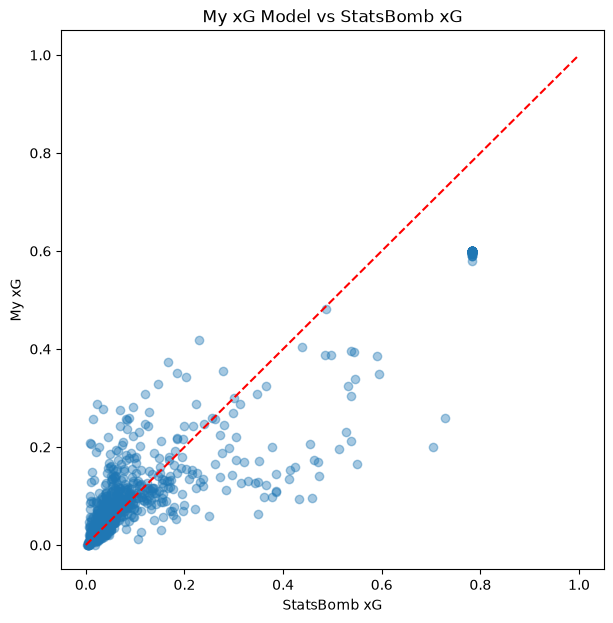

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(model_data['shot_statsbomb_xg'], model_data['my_xg'], alpha=0.4)
plt.xlabel('StatsBomb xG')
plt.ylabel('My xG')
plt.title('My xG Model vs StatsBomb xG')
plt.plot([0,1],[0,1], color='red', linestyle='--')  # reference line for perfect agreement
plt.savefig('xg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

Built a logistic regression xG model from scratch using 790 shots from the 
2024 Copa América, incorporating distance to goal, shot angle, body part, 
shot type, and defensive pressure as features.

**Key findings:**
- Distance to goal, header vs. other body parts, and open play vs. set 
  piece were all statistically significant predictors of scoring (p < 0.01).
- Shot angle and defensive pressure were not statistically significant in 
  this model (p = 0.619 and p = 0.193 respectively), likely due to angle's 
  correlation with distance reducing its independent explanatory power.
- The model's predicted probabilities correlated strongly with StatsBomb's 
  own professional xG values (r = 0.91), despite using a simpler feature 
  set with no defender/goalkeeper positioning data.
- The model correctly identifies penalty kicks as a distinct high-probability 
  shot type, clustering all five penalties in the dataset at ~60% predicted 
  conversion — reasonably close to typical real-world penalty conversion rates.

**Limitation:** in cases of divergence from StatsBomb's xG (e.g. a shot 
StatsBomb rated at 0.46 that this model rated at 0.17), the gap likely 
reflects StatsBomb's access to defender and goalkeeper positioning data 
(via freeze-frame tracking) that this simpler model does not incorporate.